In [2]:
import math
from inspect import isfunction
from functools import partial

%matplotlib inline
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from einops import rearrange, reduce
from einops.layers.torch import Rearrange

import torch
from torch import nn, einsum
import torch.nn.functional as F
import numpy as np

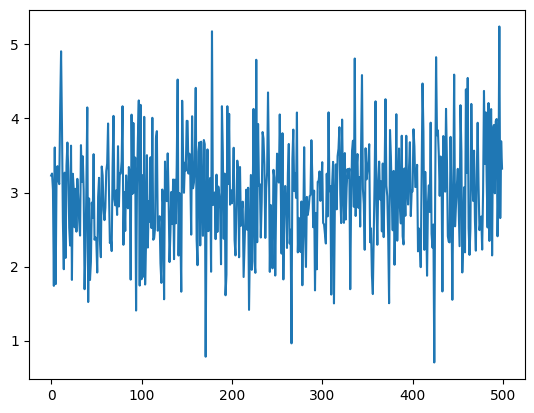

In [3]:
# mandatory task 1
# 1 create different Gaussiann noise with m and v
m = 3.0
q = 0.5
num_trajectories = 500
x0 = np.random.normal(loc=m, scale=np.sqrt(q), size=num_trajectories)

plt.plot(x0)



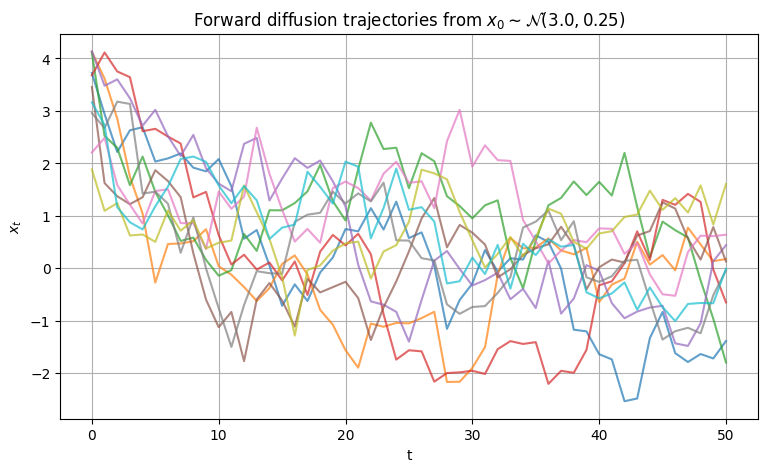

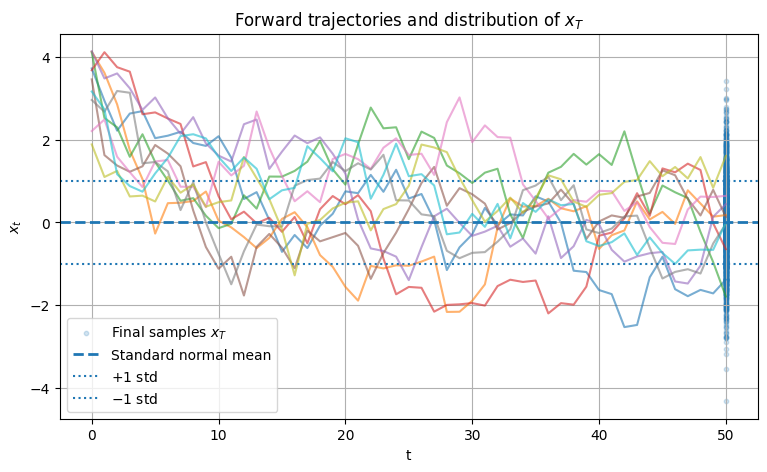

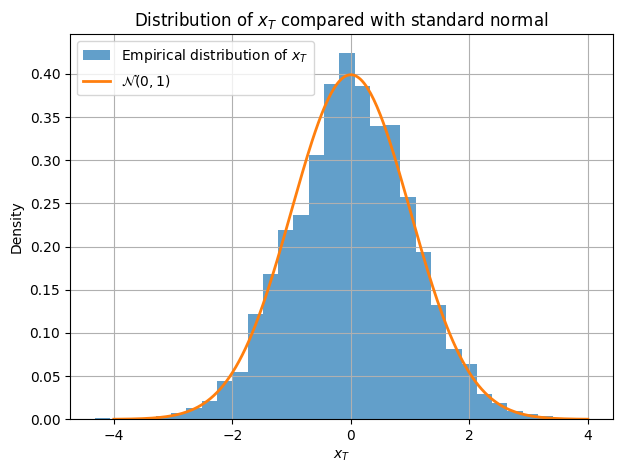

Mean of x0: 3.0011675068075236
Variance of x0: 0.5189710617778992
Mean of x_T: 0.015318629451619799
Variance of x_T: 1.0217169756821598


In [4]:
# forward process
import numpy as np
import matplotlib.pyplot as plt

# diffusion settings
T = 50
beta = 0.25
num_trajectories = 2000   # at least 100

# store all trajectories
xs = np.zeros((num_trajectories, T + 1))

# sample different x0 values
xs[:, 0] = np.random.normal(
    loc=m,
    scale=np.sqrt(q),
    size=num_trajectories
)

# forward diffusion
for t in range(1, T + 1):
    noise = np.random.normal(0, 1, size=num_trajectories)

    xs[:, t] = (
        np.sqrt(1 - beta) * xs[:, t - 1]
        + np.sqrt(beta) * noise
    )
x_T = xs[:, T]
plt.figure(figsize=(9, 5))

# Plot only a few trajectories, otherwise the figure becomes messy
for i in range(10):
    plt.plot(
        range(T + 1),
        xs[i, :],
        alpha=0.7
    )

plt.xlabel("t")
plt.ylabel(r"$x_t$")
plt.title(r"Forward diffusion trajectories from $x_0 \sim \mathcal{N}(3.0, 0.25)$")
plt.grid(True)
plt.show()

# ============================================================
# 6. Show final x_T samples on the x_t against t plot
# ============================================================

plt.figure(figsize=(9, 5))

# Plot a few trajectories
for i in range(10):
    plt.plot(
        range(T + 1),
        xs[i, :],
        alpha=0.6
    )

# Plot all final samples x_T as a vertical cloud at t = T
plt.scatter(
    np.full(num_trajectories, T),
    xs[:, T],
    s=10,
    alpha=0.2,
    label=r"Final samples $x_T$"
)

plt.axhline(0, linestyle="--", linewidth=2, label="Standard normal mean")
plt.axhline(1, linestyle=":", linewidth=1.5, label=r"$+1$ std")
plt.axhline(-1, linestyle=":", linewidth=1.5, label=r"$-1$ std")

plt.xlabel("t")
plt.ylabel(r"$x_t$")
plt.title(r"Forward trajectories and distribution of $x_T$")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 7. Histogram of x_T to verify approximately standard normal
# ============================================================

x_T = xs[:, T]

plt.figure(figsize=(7, 5))

plt.hist(
    x_T,
    bins=30,
    density=True,
    alpha=0.7,
    label=r"Empirical distribution of $x_T$"
)

# Standard normal density curve
z = np.linspace(-4, 4, 300)
standard_normal_pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * z**2)

plt.plot(
    z,
    standard_normal_pdf,
    linewidth=2,
    label=r"$\mathcal{N}(0, 1)$"
)

plt.xlabel(r"$x_T$")
plt.ylabel("Density")
plt.title(r"Distribution of $x_T$ compared with standard normal")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 8. Numerical verification
# ============================================================

print("Mean of x0:", np.mean(xs[:, 0]))
print("Variance of x0:", np.var(xs[:, 0]))

print("Mean of x_T:", np.mean(x_T))
print("Variance of x_T:", np.var(x_T))

In [5]:

# Constant beta schedule
betas = np.full(T + 1, beta)
# index 0 unused, so beta_t = betas[t]

alphas = 1.0 - betas

# alpha_bar[t] = alpha_1 * alpha_2 * ... * alpha_t
alpha_bars = np.ones(T + 1)
for t in range(1, T + 1):
    alpha_bars[t] = alpha_bars[t - 1] * alphas[t]
def reverse_posterior_mean_variance(x_t, x_0, t, betas, alphas, alpha_bars):
    """
    Compute q(x_{t-1} | x_t, x_0).

    Returns:
        mean: posterior mean
        var: posterior variance
    """

    beta_t = betas[t]
    alpha_t = alphas[t]
    alpha_bar_t = alpha_bars[t]
    alpha_bar_prev = alpha_bars[t - 1]

    coef_x0 = (
        np.sqrt(alpha_bar_prev) * beta_t
        / (1.0 - alpha_bar_t)
    )

    coef_xt = (
        np.sqrt(alpha_t) * (1.0 - alpha_bar_prev)
        / (1.0 - alpha_bar_t)
    )

    mean = coef_x0 * x_0 + coef_xt * x_t

    var = (
        (1.0 - alpha_bar_prev)
        / (1.0 - alpha_bar_t)
        * beta_t
    )

    return mean, var
def sample_reverse_step(x_t, x_0, t, betas, alphas, alpha_bars):
    """
    Sample x_{t-1} from q(x_{t-1} | x_t, x_0).
    """

    mean, var = reverse_posterior_mean_variance(
        x_t, x_0, t, betas, alphas, alpha_bars
    )

    noise = np.random.normal(0.0, 1.0, size=np.shape(x_t))

    x_prev = mean + np.sqrt(var) * noise

    return x_prev


In [6]:
print(xs.shape)
print(x_T.shape)

(2000, 51)
(2000,)


100%|██████████| 50/50 [00:00<00:00, 9631.01it/s]

3.0011675068075236
0.5189710617778992
3.0011675068075236
0.5189710617778992


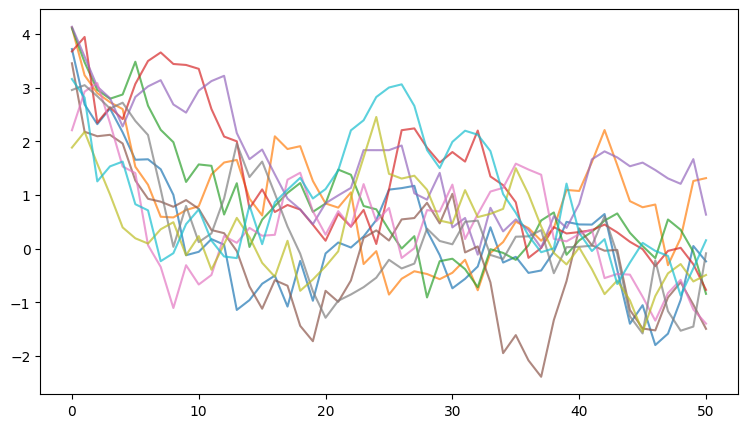

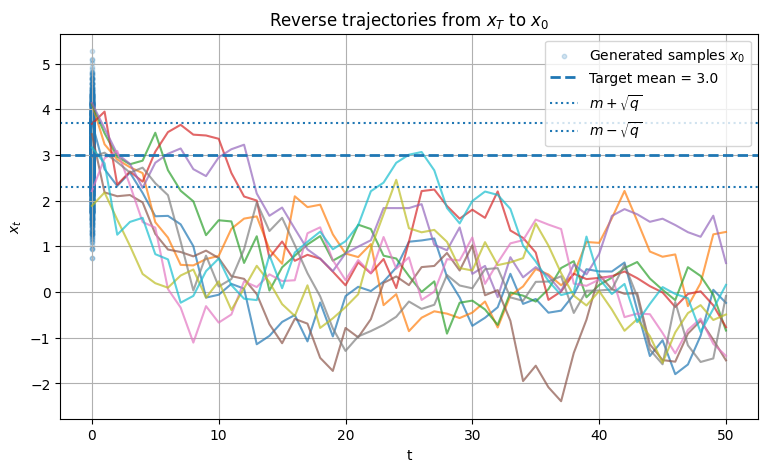

In [7]:


reverse_samples = np.zeros((num_trajectories, T + 1))

x0_known = xs[:, 0]
reverse_samples[:, T] = np.random.normal(0, 1, size=num_trajectories)

for t in tqdm(range(T, 0, -1)):
    reverse_samples[:, t - 1] = sample_reverse_step(
        reverse_samples[:, t],
        x0_known,
        t,
        betas,
        alphas,
        alpha_bars
    )
print(np.mean(reverse_samples[:, 0]))
print(np.var(reverse_samples[:, 0]))
print(np.mean(x0_known))
print(np.var(x0_known))

plt.figure(figsize=(9, 5))

for i in range(10):
    plt.plot(range(T + 1), reverse_samples[i, :], alpha=0.7)

plt.figure(figsize=(9, 5))

for i in range(10):
    plt.plot(range(T + 1), reverse_samples[i, :], alpha=0.7)

# show generated x0 distribution at t = 0
plt.scatter(
    np.full(num_trajectories, 0),
    reverse_samples[:, 0],
    s=10,
    alpha=0.2,
    label=r"Generated samples $x_0$"
)

# target distribution reference lines
target_mean = m
target_std = np.sqrt(q)

plt.axhline(target_mean, linestyle="--", linewidth=2, label=rf"Target mean = {target_mean}")
plt.axhline(target_mean + target_std, linestyle=":", linewidth=1.5, label=rf"$m+\sqrt{{q}}$")
plt.axhline(target_mean - target_std, linestyle=":", linewidth=1.5, label=rf"$m-\sqrt{{q}}$")

plt.xlabel("t")
plt.ylabel(r"$x_t$")
plt.title(r"Reverse trajectories from $x_T$ to $x_0$")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# mandatory task 2
import torch
from torch import nn
from torch.nn import functional as F


class SinusoidalEmbedding(nn.Module):
    def __init__(self, size: int, scale: float = 1.0):
        super().__init__()
        self.size = size
        self.scale = scale

    def forward(self, x: torch.Tensor):
        x = x * self.scale
        half_size = self.size // 2
        emb = torch.log(torch.Tensor([10000.0])) / (half_size - 1)
        emb = torch.exp(-emb * torch.arange(half_size))
        emb = x.unsqueeze(-1) * emb.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
        return emb

    def __len__(self):
        return self.size

In [9]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader


DATASET_PATHS = {
    "circle": "MandatoryTask2/circle_pts.npy",
    "dinohead": "MandatoryTask2/dinohead_pts.npy",
    "square": "MandatoryTask2/square_pts.npy",
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)



device: cpu


In [10]:
class SinusoidalEmbedding(nn.Module):
    """
    Sinusoidal embedding for either time steps or coordinates.

    For time:
        input shape:  (batch,)
        output shape: (batch, size)

    For coordinates:
        input shape:  (batch,)
        output shape: (batch, size)
    """

    def __init__(self, size: int, scale: float = 1.0):
        super().__init__()
        self.size = size
        self.scale = scale

    def forward(self, x: torch.Tensor):
        x = x * self.scale

        half_size = self.size // 2

        # Important: create tensors on the same device as x.
        freqs = torch.exp(
            -torch.log(torch.tensor(10000.0, device=x.device))
            * torch.arange(half_size, device=x.device)
            / (half_size - 1)
        )

        emb = x.unsqueeze(-1) * freqs.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)

        return emb

    def __len__(self):
        return self.size


class NoisePredictor(nn.Module):
    """
    MLP epsilon_theta(x_t, t).

    Input:
        x_t: noisy 2D points, shape (batch, 2)
        t:   timestep indices, shape (batch,)

    Output:
        predicted raw Gaussian noise epsilon, shape (batch, 2)
    """

    def __init__(
        self,
        time_emb_dim: int = 64,
        coord_emb_dim: int = 32,
        hidden_dim: int = 128,
    ):
        super().__init__()

        self.time_embedding = SinusoidalEmbedding(time_emb_dim, scale=1.0)
        self.coord_embedding = SinusoidalEmbedding(coord_emb_dim, scale=10.0)

        input_dim = time_emb_dim + 2 * coord_emb_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x_t: torch.Tensor, t: torch.Tensor):
        t_emb = self.time_embedding(t.float())

        x_emb = self.coord_embedding(x_t[:, 0])
        y_emb = self.coord_embedding(x_t[:, 1])

        inp = torch.cat([x_emb, y_emb, t_emb], dim=1)
        return self.net(inp)


In [11]:
def load_points(file_path: str | Path) -> torch.Tensor:
    """
    Load one .npy point dataset.

    Expected shape:
        (num_points, 2)
    """

    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(
            f"Could not find {file_path}. "
            "Check that the MandatoryTask2 folder is in the same directory as this notebook."
        )

    points = np.load(file_path)

    if points.ndim != 2 or points.shape[1] != 2:
        raise ValueError(
            f"{file_path} should have shape (N, 2), but got {points.shape}."
        )

    points = torch.tensor(points, dtype=torch.float32)
    print(f"Loaded {file_path.name}: {tuple(points.shape)}")

    return points


def make_dataloader(points: torch.Tensor, batch_size: int = 64, shuffle: bool = True):
    dataset = TensorDataset(points)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def make_schedule(
    T: int = 300,
    beta_start: float = 1e-4,
    beta_end: float = 0.02,
    device: str = device,
):
    """
    Create the diffusion noise schedule.

    alpha_t = 1 - beta_t
    alpha_bar_t = product_{i=1}^{t} alpha_i
    """

    betas = torch.linspace(beta_start, beta_end, T, device=device)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)

    schedule = {
        "T": T,
        "betas": betas,
        "alphas": alphas,
        "alpha_bars": alpha_bars,
        "sqrt_alpha_bars": torch.sqrt(alpha_bars),
        "sqrt_one_minus_alpha_bars": torch.sqrt(1.0 - alpha_bars),
    }

    print("alpha_bar_T =", alpha_bars[-1].item())
    return schedule


def q_sample(
    x0: torch.Tensor,
    t: torch.Tensor,
    noise: torch.Tensor,
    schedule: dict,
):
    """
    Sample x_t directly from q(x_t | x_0):

        x_t = sqrt(alpha_bar_t) x_0
              + sqrt(1 - alpha_bar_t) epsilon
    """

    sqrt_ab_t = schedule["sqrt_alpha_bars"][t].unsqueeze(1)
    sqrt_omab_t = schedule["sqrt_one_minus_alpha_bars"][t].unsqueeze(1)

    return sqrt_ab_t * x0 + sqrt_omab_t * noise


In [12]:
def train_noise_predictor(
    points: torch.Tensor,
    *,
    T: int = 300,
    beta_start: float = 1e-4,
    beta_end: float = 0.02,
    batch_size: int = 64,
    num_epochs: int = 5000,
    lr: float = 1e-3,
    time_emb_dim: int = 64,
    coord_emb_dim: int = 32,
    hidden_dim: int = 128,
    print_every: int = 500,
    checkpoint_steps: tuple[int, ...] = (0, 1000, 2000, 3000, 4000, 5000),
    checkpoint_num_samples: int = 1000,
    device: str = device,
):
    """
    Train one diffusion noise-prediction model for one 2D point dataset.

    This version keeps the original training strength: it trains for num_epochs,
    and each epoch loops through the whole dataloader.

    At the same time, it records reverse-sampling checkpoints at selected
    optimizer steps, e.g. 0, 1000, 2000, ... . This satisfies the Task 2 / 4.2
    requirement without weakening the original model.
    """

    points = points.to(device)
    dataloader = make_dataloader(points, batch_size=batch_size, shuffle=True)

    schedule = make_schedule(
        T=T,
        beta_start=beta_start,
        beta_end=beta_end,
        device=device,
    )

    model = NoisePredictor(
        time_emb_dim=time_emb_dim,
        coord_emb_dim=coord_emb_dim,
        hidden_dim=hidden_dim,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epoch_loss_history = []
    step_loss_history = []
    checkpoint_samples = {}
    checkpoint_set = set(checkpoint_steps or ())

    global_step = 0

    # Reverse samples from the untrained model.
    if 0 in checkpoint_set:
        checkpoint_samples[0] = sample_points(
            model,
            schedule,
            num_samples=checkpoint_num_samples,
            device=device,
        )

    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []

        for (x0,) in dataloader:
            x0 = x0.to(device)
            batch_size_now = x0.shape[0]

            # Random timestep for each point in the batch.
            t = torch.randint(0, T, (batch_size_now,), device=device)

            # Raw standard Gaussian noise epsilon ~ N(0, I).
            noise = torch.randn_like(x0)

            # q_sample applies the time-dependent scaling:
            # x_t = sqrt(alpha_bar_t) x_0 + sqrt(1 - alpha_bar_t) epsilon
            x_t = q_sample(x0, t, noise, schedule)

            # Model predicts raw epsilon, not the scaled noise.
            pred_noise = model(x_t, t)

            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            global_step += 1
            epoch_losses.append(loss.item())
            step_loss_history.append(loss.item())

            # Save reverse-sampling results at required training stages.
            if global_step in checkpoint_set:
                checkpoint_samples[global_step] = sample_points(
                    model,
                    schedule,
                    num_samples=checkpoint_num_samples,
                    device=device,
                )

        mean_loss = float(np.mean(epoch_losses))
        epoch_loss_history.append(mean_loss)

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:5d}/{num_epochs}, "
                f"global step = {global_step:6d}, "
                f"mean loss = {mean_loss:.6f}"
            )

    # If the exact final step was not requested, still save the final model output.
    if global_step not in checkpoint_samples:
        checkpoint_samples[global_step] = sample_points(
            model,
            schedule,
            num_samples=checkpoint_num_samples,
            device=device,
        )

    return model, schedule, epoch_loss_history, step_loss_history, checkpoint_samples


In [13]:
@torch.no_grad()
def sample_points(
    model: nn.Module,
    schedule: dict,
    *,
    num_samples: int = 1000,
    device: str = device,
):
    """
    Reverse diffusion sampling.

    Start from x_T ~ N(0, I), then repeatedly use the model prediction
    epsilon_theta(x_t, t) to move from x_t to x_{t-1}.

    This keeps the same sampling formula as the first good version of the notebook.
    """

    model.eval()

    T = schedule["T"]
    betas = schedule["betas"]
    alphas = schedule["alphas"]
    alpha_bars = schedule["alpha_bars"]

    x = torch.randn(num_samples, 2, device=device)

    for time_step in reversed(range(T)):
        t = torch.full(
            (num_samples,),
            time_step,
            device=device,
            dtype=torch.long,
        )

        pred_noise = model(x, t)

        alpha_t = alphas[time_step]
        beta_t = betas[time_step]
        alpha_bar_t = alpha_bars[time_step]

        coef = (1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)
        mean = (1.0 / torch.sqrt(alpha_t)) * (x - coef * pred_noise)

        if time_step > 0:
            z = torch.randn_like(x)
            x = mean + torch.sqrt(beta_t) * z
        else:
            x = mean

    return x.cpu()


In [14]:
def plot_checkpoint_samples(
    dataset_name: str,
    real_points: torch.Tensor,
    checkpoint_samples: dict[int, torch.Tensor],
    *,
    max_cols: int = 3,
):
    """
    Scatter plots of reverse-sampled 2D points at different training stages.
    """

    real_np = real_points.detach().cpu().numpy()
    steps = sorted(checkpoint_samples.keys())

    num_plots = len(steps) + 1
    cols = min(max_cols, num_plots)
    rows = int(np.ceil(num_plots / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)

    axes[0].scatter(real_np[:, 0], real_np[:, 1], s=5)
    axes[0].axis("equal")
    axes[0].grid(True)
    axes[0].set_title(f"{dataset_name}: original data")

    for ax, step in zip(axes[1:], steps):
        gen_np = checkpoint_samples[step].detach().cpu().numpy()
        ax.scatter(gen_np[:, 0], gen_np[:, 1], s=5)
        ax.axis("equal")
        ax.grid(True)
        ax.set_title(f"reverse samples after {step} optimizer steps")

    for ax in axes[num_plots:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def plot_loss_history(
    dataset_name: str,
    epoch_loss_history: list[float],
    step_loss_history: list[float] | None = None,
    *,
    smoothing_window: int = 100,
):
    """
    Plot training loss. The epoch curve is close to the original notebook;
    the optional step curve is useful for the checkpoint-based analysis.
    """

    plt.figure(figsize=(6, 4))
    plt.plot(epoch_loss_history)
    plt.xlabel("epoch")
    plt.ylabel("mean MSE loss")
    plt.title(f"{dataset_name}: training loss per epoch")
    plt.grid(True)
    plt.show()

    if step_loss_history is not None and len(step_loss_history) > 0:
        steps = np.arange(1, len(step_loss_history) + 1)
        plt.figure(figsize=(7, 4))
        plt.plot(steps, step_loss_history, alpha=0.25, label="raw step loss")

        if len(step_loss_history) >= smoothing_window:
            kernel = np.ones(smoothing_window) / smoothing_window
            smooth = np.convolve(step_loss_history, kernel, mode="valid")
            smooth_steps = np.arange(smoothing_window, len(step_loss_history) + 1)
            plt.plot(smooth_steps, smooth, label=f"{smoothing_window}-step moving average")

        plt.xlabel("optimizer step")
        plt.ylabel("MSE loss")
        plt.title(f"{dataset_name}: training loss per optimizer step")
        plt.legend()
        plt.grid(True)
        plt.show()


def plot_dataset_result(
    dataset_name: str,
    real_points: torch.Tensor,
    generated_points: torch.Tensor,
    epoch_loss_history: list[float],
    step_loss_history: list[float] | None = None,
    checkpoint_samples: dict[int, torch.Tensor] | None = None,
):
    """
    Plot original data, final generated points, training-stage samples, and loss.
    """

    real_np = real_points.detach().cpu().numpy()
    gen_np = generated_points.detach().cpu().numpy()

    plt.figure(figsize=(5, 5))
    plt.scatter(real_np[:, 0], real_np[:, 1], s=5)
    plt.axis("equal")
    plt.grid(True)
    plt.title(f"{dataset_name}: original data")
    plt.show()

    plt.figure(figsize=(5, 5))
    plt.scatter(gen_np[:, 0], gen_np[:, 1], s=5)
    plt.axis("equal")
    plt.grid(True)
    plt.title(f"{dataset_name}: final generated samples")
    plt.show()

    if checkpoint_samples is not None:
        plot_checkpoint_samples(dataset_name, real_points, checkpoint_samples)

    plot_loss_history(dataset_name, epoch_loss_history, step_loss_history)


def run_one_dataset(
    dataset_name: str,
    file_path: str | Path,
    *,
    num_epochs: int = 5000,
    checkpoint_steps: tuple[int, ...] = (0, 1000, 2000, 3000, 4000, 5000),
    num_samples: int = 1000,
    batch_size: int = 64,
    T: int = 300,
    beta_start: float = 1e-4,
    beta_end: float = 0.02,
    lr: float = 1e-3,
    plot: bool = True,
    device: str = device,
):
    """
    Complete pipeline for one dataset:

        load data
        train model for the original number of epochs
        sample final generated points
        plot checkpoint samples at selected optimizer steps
    """

    print(f"\n========== {dataset_name} ==========")

    points = load_points(file_path)

    model, schedule, epoch_loss_history, step_loss_history, checkpoint_samples = train_noise_predictor(
        points,
        T=T,
        beta_start=beta_start,
        beta_end=beta_end,
        batch_size=batch_size,
        num_epochs=num_epochs,
        lr=lr,
        checkpoint_steps=checkpoint_steps,
        checkpoint_num_samples=num_samples,
        device=device,
    )

    generated = sample_points(
        model,
        schedule,
        num_samples=num_samples,
        device=device,
    )

    if plot:
        plot_dataset_result(
            dataset_name,
            points,
            generated,
            epoch_loss_history,
            step_loss_history,
            checkpoint_samples,
        )

    return {
        "name": dataset_name,
        "points": points,
        "model": model,
        "schedule": schedule,
        "epoch_loss_history": epoch_loss_history,
        "step_loss_history": step_loss_history,
        "checkpoint_samples": checkpoint_samples,
        "generated": generated,
        "config": {
            "num_epochs": num_epochs,
            "checkpoint_steps": checkpoint_steps,
            "num_samples": num_samples,
            "batch_size": batch_size,
            "T": T,
            "beta_start": beta_start,
            "beta_end": beta_end,
            "lr": lr,
        },
    }


def run_all_datasets(
    dataset_paths: dict[str, str | Path] = DATASET_PATHS,
    *,
    num_epochs: int = 5000,
    checkpoint_steps: tuple[int, ...] = (0, 1000, 2000, 3000, 4000, 5000),
    num_samples: int = 1000,
    batch_size: int = 64,
    T: int = 300,
    beta_start: float = 1e-4,
    beta_end: float = 0.02,
    lr: float = 1e-3,
    plot: bool = True,
    device: str = device,
):
    """
    Run the same Mandatory Task 2 pipeline for circle, dinohead, and square.
    """

    results = {}

    for dataset_name, file_path in dataset_paths.items():
        results[dataset_name] = run_one_dataset(
            dataset_name,
            file_path,
            num_epochs=num_epochs,
            checkpoint_steps=checkpoint_steps,
            num_samples=num_samples,
            batch_size=batch_size,
            T=T,
            beta_start=beta_start,
            beta_end=beta_end,
            lr=lr,
            plot=plot,
            device=device,
        )

    return results


In [15]:
def plot_beta_end_study(
    beta_results: dict[float, dict],
    *,
    dataset_name: str,
    max_cols: int = 3,
):
    """
    Compare final generated samples and loss curves for different beta_end values.
    """

    beta_values = list(beta_results.keys())
    num_plots = len(beta_values)
    cols = min(max_cols, num_plots)
    rows = int(np.ceil(num_plots / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, beta_end in zip(axes, beta_values):
        result = beta_results[beta_end]
        gen_np = result["generated"].detach().cpu().numpy()
        ax.scatter(gen_np[:, 0], gen_np[:, 1], s=5)
        ax.axis("equal")
        ax.grid(True)
        ax.set_title(f"{dataset_name}: beta_end={beta_end}")

    for ax in axes[num_plots:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    for beta_end in beta_values:
        loss_history = beta_results[beta_end]["step_loss_history"]
        if len(loss_history) >= 100:
            kernel = np.ones(100) / 100
            smooth = np.convolve(loss_history, kernel, mode="valid")
            smooth_steps = np.arange(100, len(loss_history) + 1)
            plt.plot(smooth_steps, smooth, label=f"beta_end={beta_end}")
        else:
            plt.plot(loss_history, label=f"beta_end={beta_end}")

    plt.xlabel("optimizer step")
    plt.ylabel("MSE loss")
    plt.title(f"{dataset_name}: beta_end study, training loss")
    plt.legend()
    plt.grid(True)
    plt.show()


def run_beta_end_study(
    dataset_name: str = "circle",
    beta_end_values: tuple[float, ...] = (0.005, 0.02, 0.05),
    *,
    dataset_paths: dict[str, str | Path] = DATASET_PATHS,
    num_epochs: int = 2000,
    checkpoint_steps: tuple[int, ...] = (0, 1000, 2000, 3000, 4000, 5000),
    num_samples: int = 1000,
    batch_size: int = 64,
    T: int = 300,
    beta_start: float = 1e-4,
    lr: float = 1e-3,
    plot: bool = True,
    device: str = device,
):
    """
    Hyperparameter study for Task 2 / 4.2.

    This trains one separate model for each beta_end value while keeping the
    dataset, architecture, learning rate, batch size, T, and number of epochs fixed.
    """

    if dataset_name not in dataset_paths:
        raise ValueError(
            f"Unknown dataset_name={dataset_name!r}. "
            f"Available datasets: {list(dataset_paths.keys())}"
        )

    beta_results = {}

    for beta_end in beta_end_values:
        print("\n" + "=" * 70)
        print(f"beta_end study: dataset={dataset_name}, beta_end={beta_end}")
        print("=" * 70)

        result = run_one_dataset(
            dataset_name=f"{dataset_name}, beta_end={beta_end}",
            file_path=dataset_paths[dataset_name],
            num_epochs=num_epochs,
            checkpoint_steps=checkpoint_steps,
            num_samples=num_samples,
            batch_size=batch_size,
            T=T,
            beta_start=beta_start,
            beta_end=beta_end,
            lr=lr,
            plot=False,
            device=device,
        )
        beta_results[beta_end] = result

    if plot:
        plot_beta_end_study(beta_results, dataset_name=dataset_name)

    return beta_results



========== circle ==========
Loaded circle_pts.npy: (1000, 2)
alpha_bar_T = 0.04805843159556389
Epoch     0/5000, global step =     16, mean loss = 1.037031
Epoch   500/5000, global step =   8016, mean loss = 0.486010
Epoch  1000/5000, global step =  16016, mean loss = 0.521597
Epoch  1500/5000, global step =  24016, mean loss = 0.550399
Epoch  2000/5000, global step =  32016, mean loss = 0.500580
Epoch  2500/5000, global step =  40016, mean loss = 0.536213
Epoch  3000/5000, global step =  48016, mean loss = 0.488930
Epoch  3500/5000, global step =  56016, mean loss = 0.541535
Epoch  4000/5000, global step =  64016, mean loss = 0.494040
Epoch  4500/5000, global step =  72016, mean loss = 0.485405


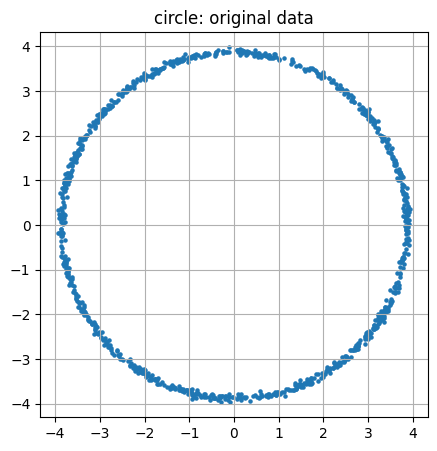

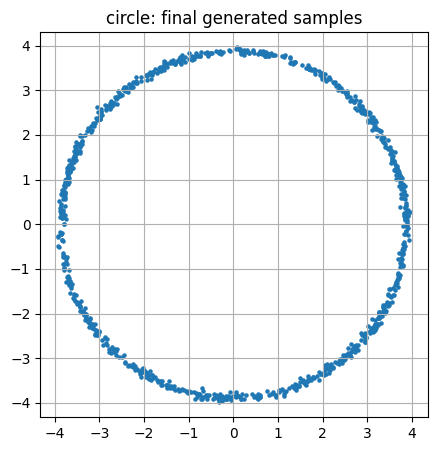

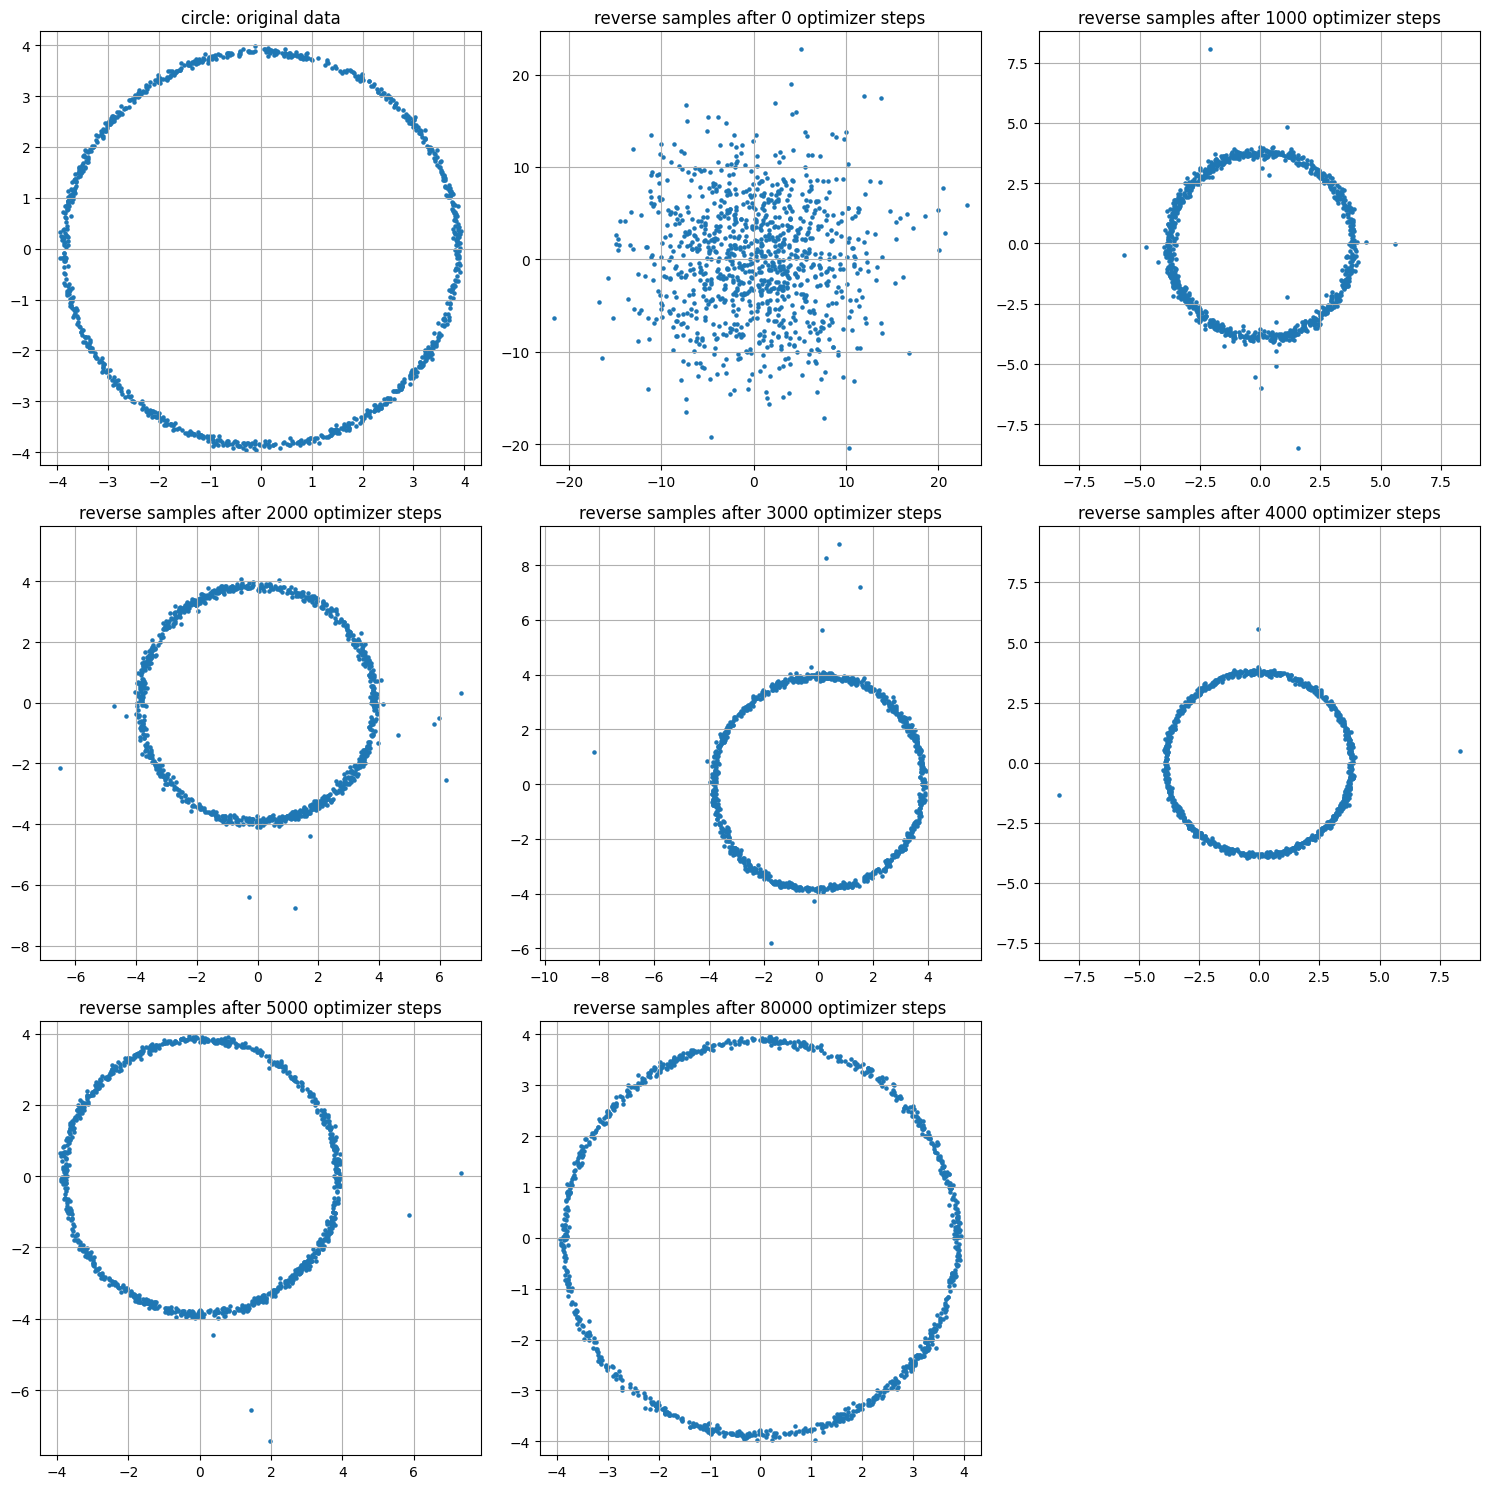

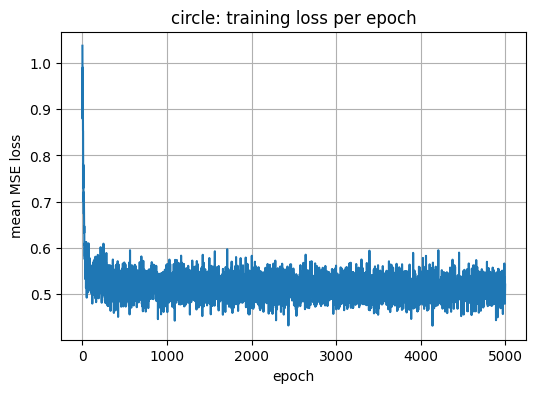

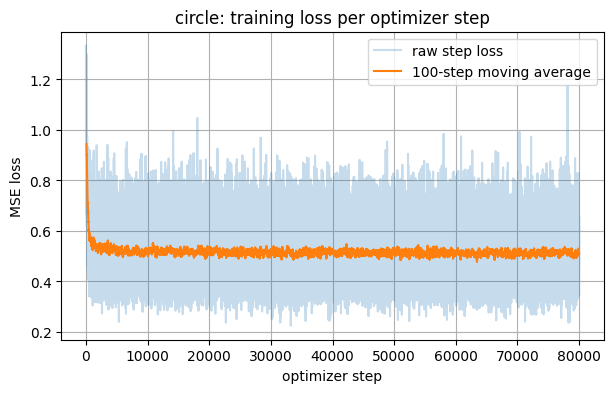


========== dinohead ==========
Loaded dinohead_pts.npy: (10240, 2)
alpha_bar_T = 0.04805843159556389
Epoch     0/5000, global step =    160, mean loss = 0.760533
Epoch   500/5000, global step =  80160, mean loss = 0.551743
Epoch  1000/5000, global step = 160160, mean loss = 0.542483
Epoch  1500/5000, global step = 240160, mean loss = 0.550592
Epoch  2000/5000, global step = 320160, mean loss = 0.540527
Epoch  2500/5000, global step = 400160, mean loss = 0.548836
Epoch  3000/5000, global step = 480160, mean loss = 0.534609
Epoch  3500/5000, global step = 560160, mean loss = 0.547128
Epoch  4000/5000, global step = 640160, mean loss = 0.534393
Epoch  4500/5000, global step = 720160, mean loss = 0.546452


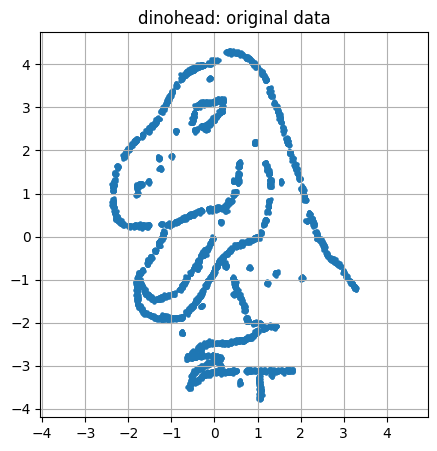

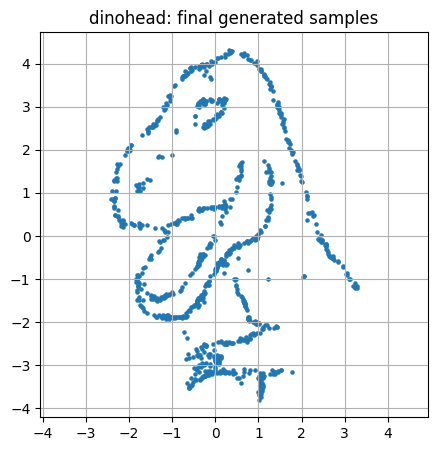

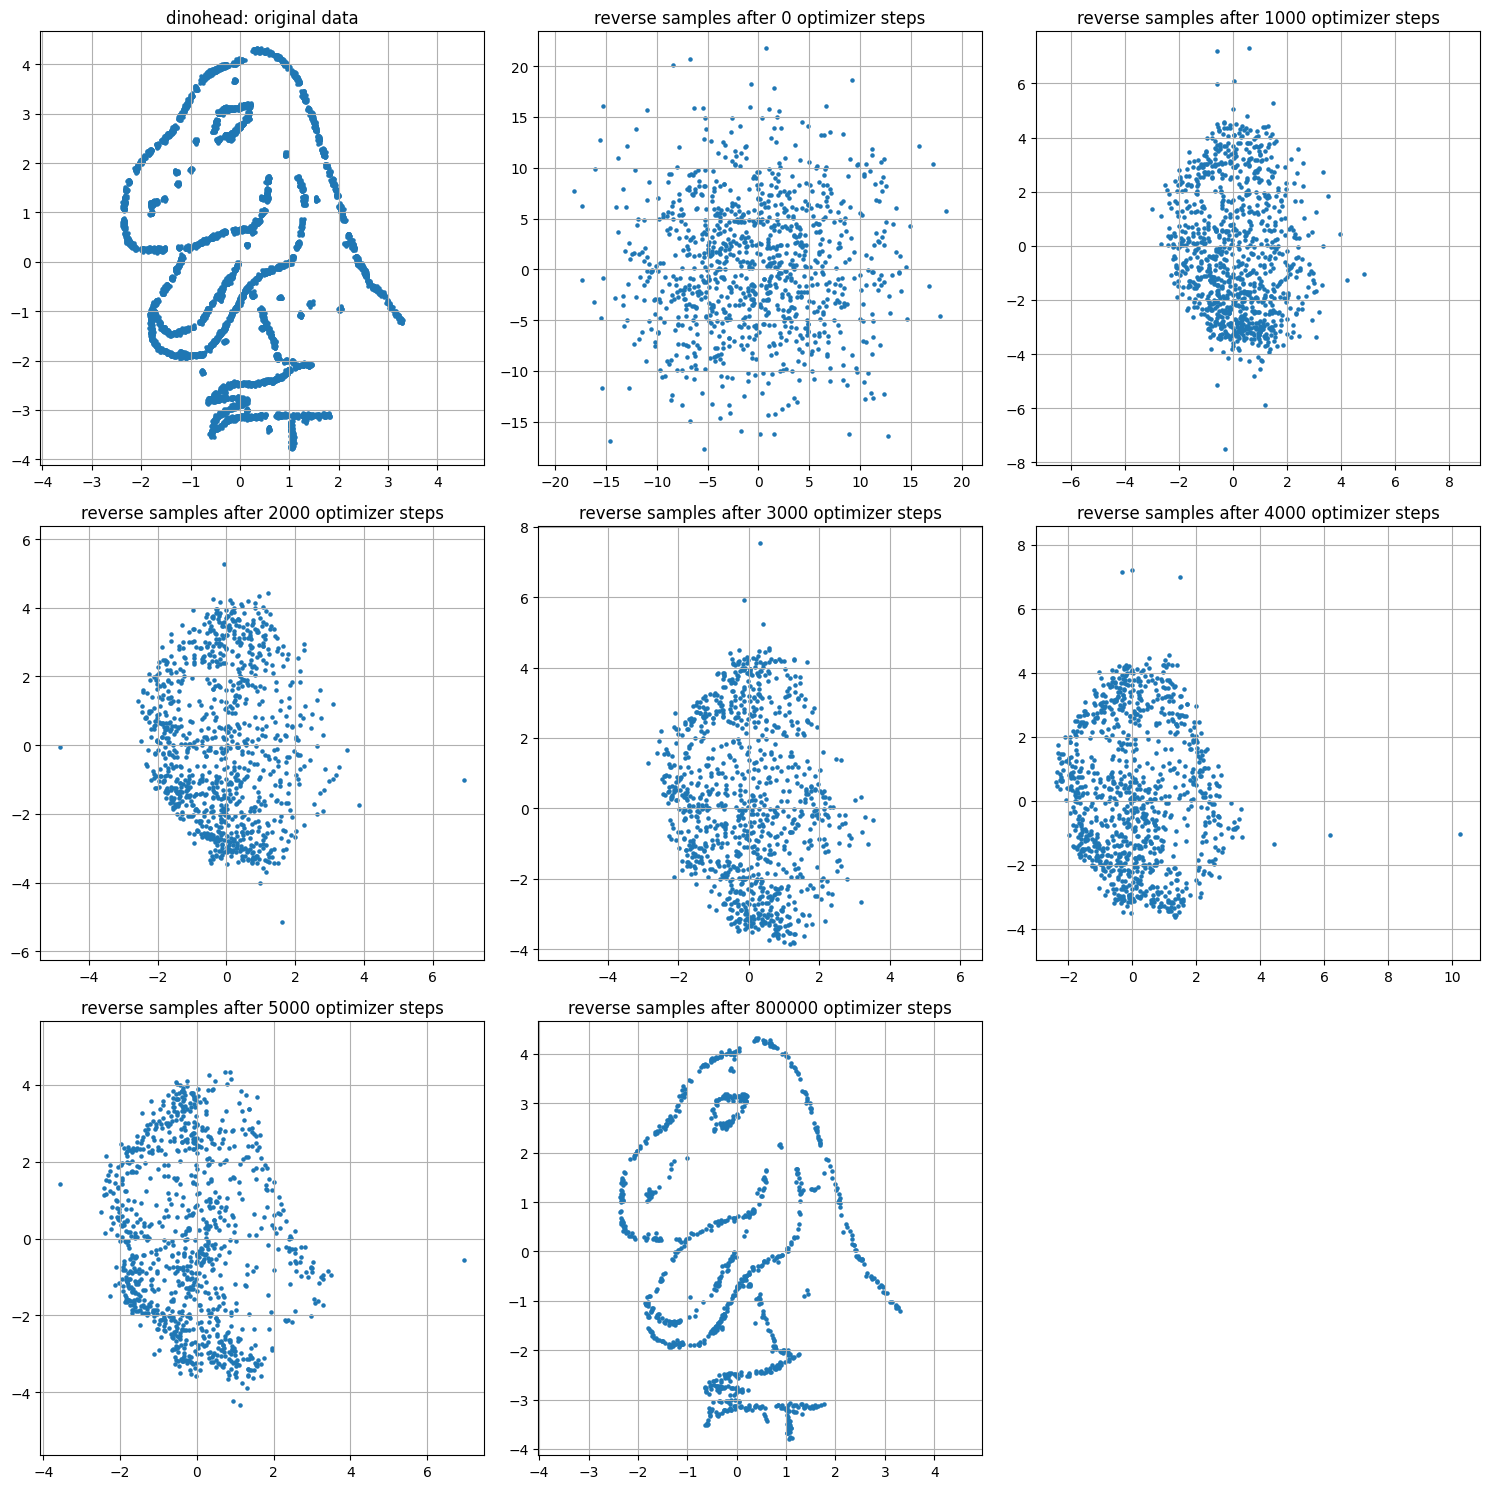

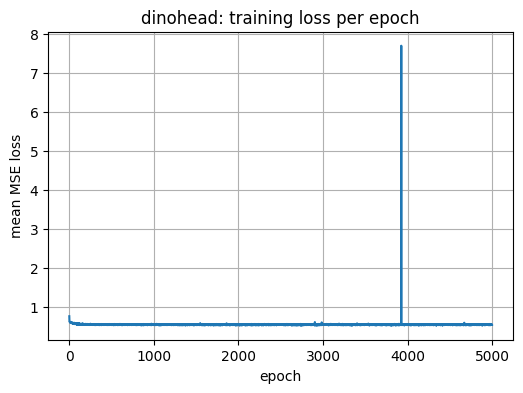

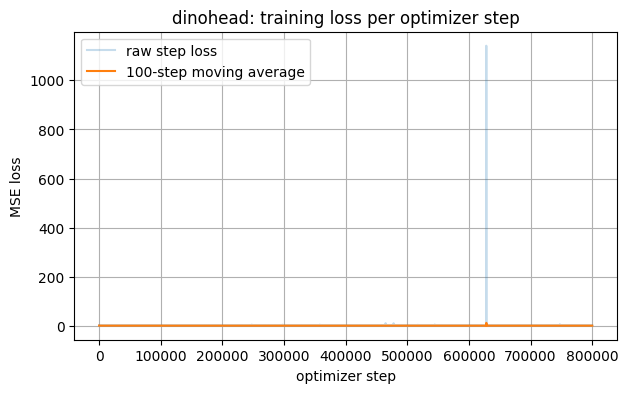


========== square ==========
Loaded square_pts.npy: (1000, 2)
alpha_bar_T = 0.04805843159556389
Epoch     0/5000, global step =     16, mean loss = 1.008868
Epoch   500/5000, global step =   8016, mean loss = 0.562225
Epoch  1000/5000, global step =  16016, mean loss = 0.554361
Epoch  1500/5000, global step =  24016, mean loss = 0.551034
Epoch  2000/5000, global step =  32016, mean loss = 0.533113
Epoch  2500/5000, global step =  40016, mean loss = 0.534508
Epoch  3000/5000, global step =  48016, mean loss = 0.529313
Epoch  3500/5000, global step =  56016, mean loss = 0.527029
Epoch  4000/5000, global step =  64016, mean loss = 0.535094
Epoch  4500/5000, global step =  72016, mean loss = 0.542107


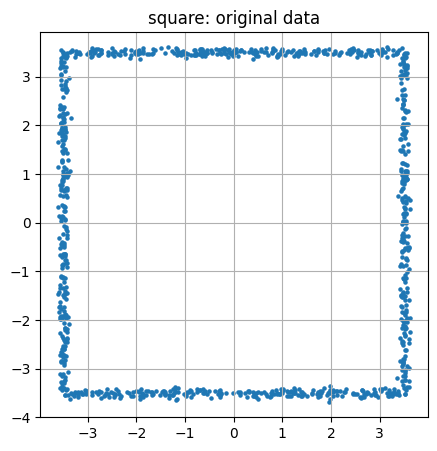

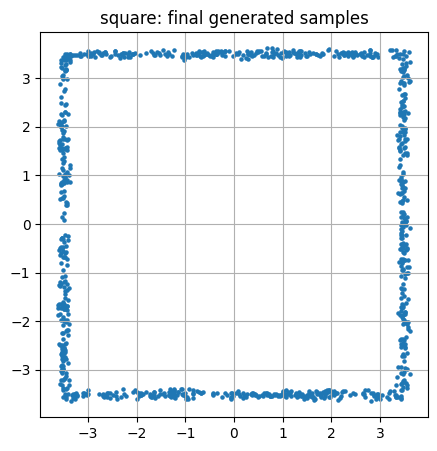

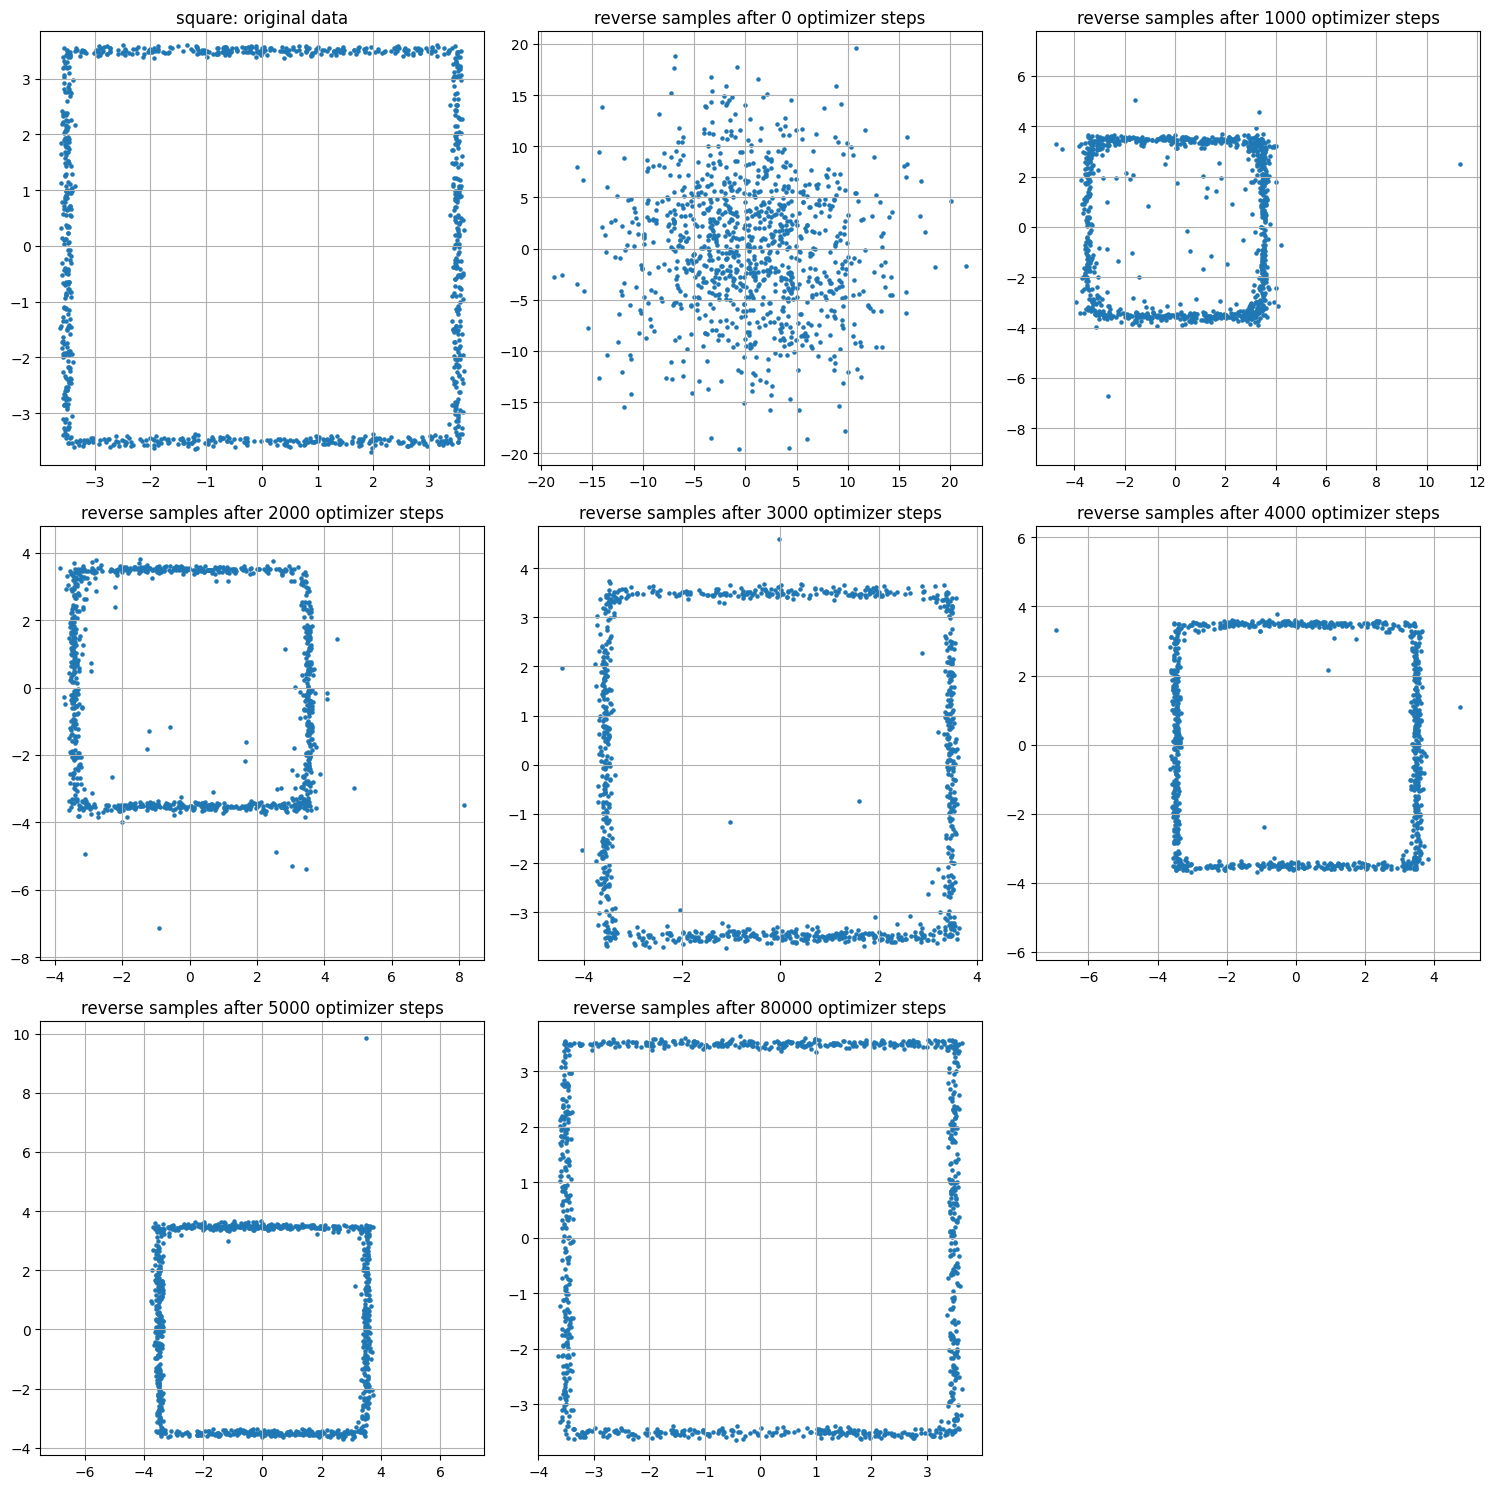

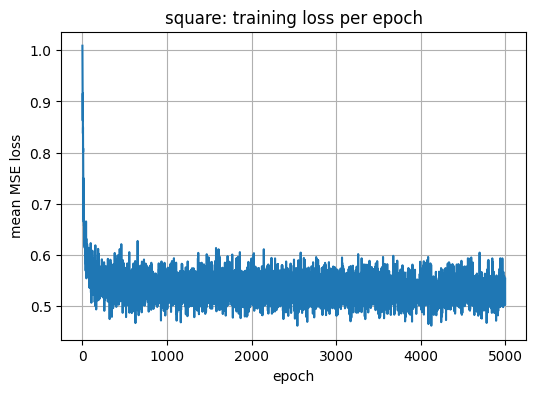

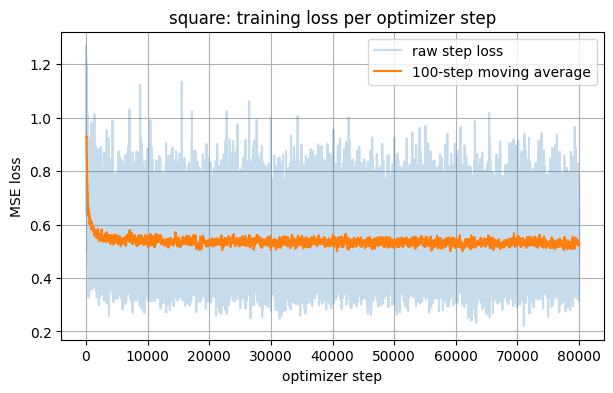

In [16]:
# ============================================================
# Mandatory Task 2 / 4.2 experiment runner
# ============================================================
# This trains one model for each 2D dataset.
# It keeps the original training strength: num_epochs=5000.
# It also saves reverse-sampling scatter plots at selected optimizer steps.

results = run_all_datasets(
    num_epochs=5000,
    checkpoint_steps=(0, 1000, 2000, 3000, 4000, 5000),
    num_samples=1000,
    batch_size=64,
    T=300,
    beta_end=0.02,
    lr=1e-3,
    plot=True,
)


## 4.2 Additional Hyperparameter Study: `beta_end`

The additional hyperparameter studied here is `beta_end`, the final value of the linear noise schedule.

This is useful because `beta_end` controls how strongly the forward process destroys the original 2D point structure near the final diffusion step.

- If `beta_end` is too small, then `x_T` may not be close enough to a standard 2D Gaussian.
- If `beta_end` is too large, the reverse process becomes harder because the data structure is destroyed more aggressively.
- A middle value often gives a better trade-off.


In [17]:
def plot_beta_end_study(
    beta_results: dict[float, dict],
    *,
    dataset_name: str,
    max_cols: int = 3,
):
    """
    Compare final generated samples and loss curves for different beta_end values.
    """

    beta_values = list(beta_results.keys())
    num_plots = len(beta_values)
    cols = min(max_cols, num_plots)
    rows = int(np.ceil(num_plots / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, beta_end in zip(axes, beta_values):
        result = beta_results[beta_end]
        gen_np = result["generated"].detach().cpu().numpy()
        ax.scatter(gen_np[:, 0], gen_np[:, 1], s=5)
        ax.axis("equal")
        ax.grid(True)
        ax.set_title(f"{dataset_name}: beta_end={beta_end}")

    for ax in axes[num_plots:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    for beta_end in beta_values:
        loss_history = beta_results[beta_end]["step_loss_history"]
        if len(loss_history) >= 100:
            kernel = np.ones(100) / 100
            smooth = np.convolve(loss_history, kernel, mode="valid")
            smooth_steps = np.arange(100, len(loss_history) + 1)
            plt.plot(smooth_steps, smooth, label=f"beta_end={beta_end}")
        else:
            plt.plot(loss_history, label=f"beta_end={beta_end}")

    plt.xlabel("optimizer step")
    plt.ylabel("MSE loss")
    plt.title(f"{dataset_name}: beta_end study, training loss")
    plt.legend()
    plt.grid(True)
    plt.show()


def run_beta_end_study(
    dataset_name: str = "circle",
    beta_end_values: tuple[float, ...] = (0.005, 0.02, 0.05),
    *,
    dataset_paths: dict[str, str | Path] = DATASET_PATHS,
    num_epochs: int = 2000,
    checkpoint_steps: tuple[int, ...] = (0, 1000, 2000, 3000, 4000, 5000),
    num_samples: int = 1000,
    batch_size: int = 64,
    T: int = 300,
    beta_start: float = 1e-4,
    lr: float = 1e-3,
    plot: bool = True,
    device: str = device,
):
    """
    Hyperparameter study for Task 2 / 4.2.

    This trains one separate model for each beta_end value while keeping the
    dataset, architecture, learning rate, batch size, T, and number of epochs fixed.
    """

    if dataset_name not in dataset_paths:
        raise ValueError(
            f"Unknown dataset_name={dataset_name!r}. "
            f"Available datasets: {list(dataset_paths.keys())}"
        )

    beta_results = {}

    for beta_end in beta_end_values:
        print("\n" + "=" * 70)
        print(f"beta_end study: dataset={dataset_name}, beta_end={beta_end}")
        print("=" * 70)

        result = run_one_dataset(
            dataset_name=f"{dataset_name}, beta_end={beta_end}",
            file_path=dataset_paths[dataset_name],
            num_epochs=num_epochs,
            checkpoint_steps=checkpoint_steps,
            num_samples=num_samples,
            batch_size=batch_size,
            T=T,
            beta_start=beta_start,
            beta_end=beta_end,
            lr=lr,
            plot=False,
            device=device,
        )
        beta_results[beta_end] = result

    if plot:
        plot_beta_end_study(beta_results, dataset_name=dataset_name)

    return beta_results



beta_end study: dataset=circle, beta_end=0.005

========== circle, beta_end=0.005 ==========
Loaded circle_pts.npy: (1000, 2)
alpha_bar_T = 0.4647384583950043
Epoch     0/2000, global step =     16, mean loss = 1.056058
Epoch   500/2000, global step =   8016, mean loss = 0.578493
Epoch  1000/2000, global step =  16016, mean loss = 0.576871
Epoch  1500/2000, global step =  24016, mean loss = 0.537175

beta_end study: dataset=circle, beta_end=0.02

========== circle, beta_end=0.02 ==========
Loaded circle_pts.npy: (1000, 2)
alpha_bar_T = 0.04805843159556389
Epoch     0/2000, global step =     16, mean loss = 0.993329
Epoch   500/2000, global step =   8016, mean loss = 0.516230
Epoch  1000/2000, global step =  16016, mean loss = 0.504549
Epoch  1500/2000, global step =  24016, mean loss = 0.528119

beta_end study: dataset=circle, beta_end=0.05

========== circle, beta_end=0.05 ==========
Loaded circle_pts.npy: (1000, 2)
alpha_bar_T = 0.000479053589515388
Epoch     0/2000, global step =  

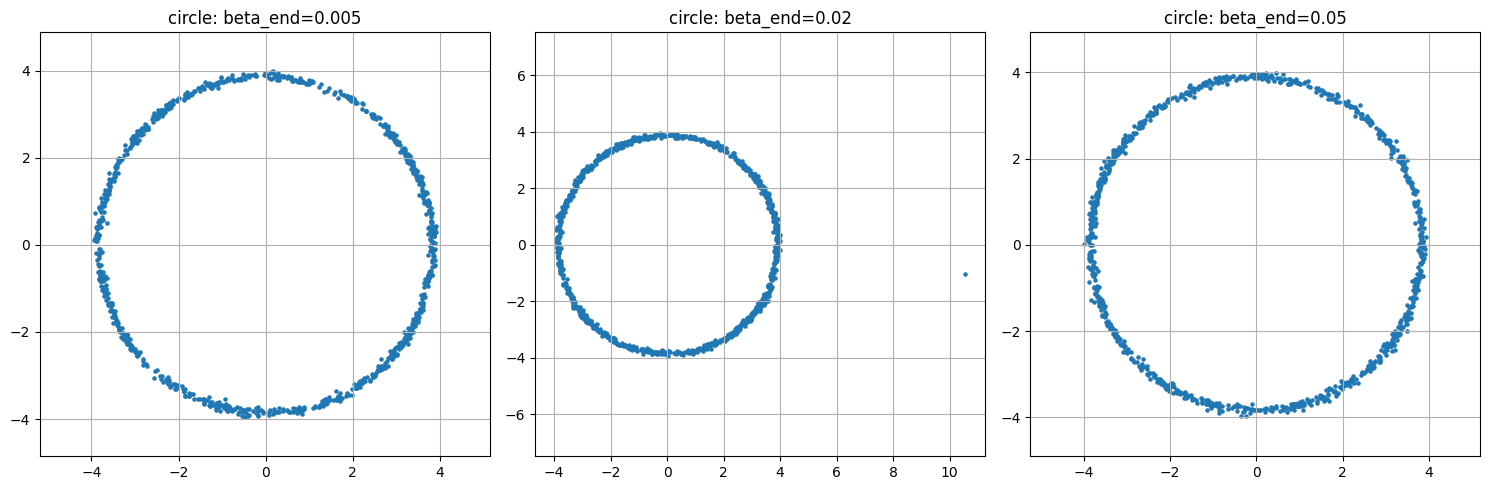

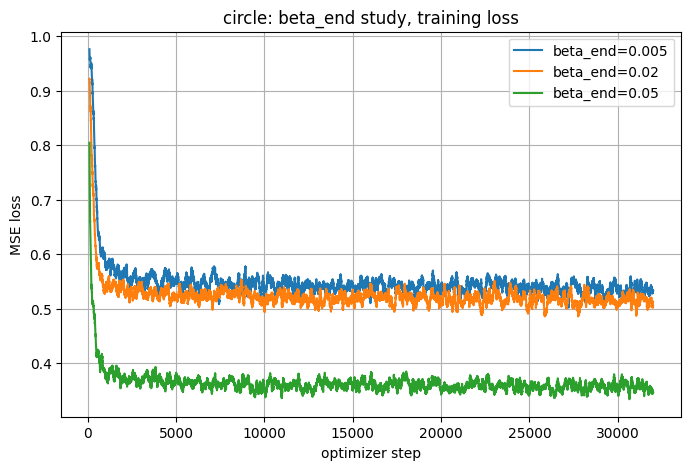

In [18]:
# Run the beta_end hyperparameter study.
# This is intentionally separated from the main three-dataset run.
# You can change dataset_name to "dinohead" or "square".

beta_study = run_beta_end_study(
    dataset_name="circle",
    beta_end_values=(0.005, 0.02, 0.05),
    num_epochs=2000,
    checkpoint_steps=(0, 1000, 2000, 3000, 4000, 5000),
    num_samples=1000,
    batch_size=64,
    T=300,
    lr=1e-3,
    plot=True,
)


### Suggested analysis text for the report

In this hyperparameter study, I varied `beta_end` while keeping the model architecture, number of diffusion steps, learning rate, batch size, and training length fixed. The value of `beta_end` controls the final strength of the forward noising process. When `beta_end` is small, the final noised distribution may still contain visible structure from the original data, so the assumption that reverse sampling starts from a standard Gaussian is less accurate. When `beta_end` is large, the forward process destroys the structure more strongly, but the reverse denoising problem can become harder. The generated samples and loss curves show how this trade-off affects sample quality.
